# 주얼리 이커머스 Meta 광고 성과 구조 분석
**어떤 운영 방식과 광고 소재가 Meta 광고 성과를 만드는가?**

---

## 프로젝트 개요

| 항목 | 내용 |
|------|------|
| 분석 대상 | 원석팔찌·커플세트 주얼리 이커머스 A사 |
| 분석 기간 | 2025.01.01 ~ 2025.12.31 (1년 전체) |
| 데이터 | Meta 광고 관리자 + 자사몰 주문 연계 데이터 |
| 운영 규모 | 캠페인 102 / 광고세트 128 / 광고 1,331 |

### 분석 목적
1. Meta 광고 알고리즘 최적화와 관련된 **비효율 구간 발견**
2. 실제 성과를 만드는 **메시지·소재 전략 도출**
3. 재현 가능한 **광고 운영 기준 수립**

### 주요 지표
- **ROAS** (Return On Ad Spend) = 매출 ÷ 광고비
- **CTR** (Click Through Rate) = 클릭 수 ÷ 노출 수

> ※ 기업 데이터 보호를 위해 구체 금액·캠페인명은 마스킹 처리되었습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
# 데이터 로드
ads_2025 = pd.read_csv('2025_meta_ads_daily_final.csv', encoding='utf-8-sig')
products = pd.read_csv('상품정보_20251030.csv', encoding='utf-8-sig')

# URL에서 product_no 추출 후 상품 정보 병합
ads_2025['product_no'] = pd.to_numeric(
    ads_2025['웹사이트 URL'].str.extract(r'/(\d+)/')[0], errors='coerce'
)
products['product_no'] = pd.to_numeric(products['product_no'], errors='coerce')
products = products.dropna(subset=['product_no'])

ads_df = pd.merge(
    ads_2025,
    products[['product_no', 'product_name']],
    on='product_no',
    how='left'
)

print(f"광고 데이터: {ads_df.shape[0]:,}행 × {ads_df.shape[1]}열")
print(f"분석 기간: {ads_df['일'].min()} ~ {ads_df['일'].max()}")

광고 데이터: 21,197행 × 40열
분석 기간: 2025-01-01 ~ 2025-12-31


---
## PART 1 — 광고 성과 구조 분석 (Performance)

> "성과를 만드는 운영 구조인가?"

Meta 광고는 7일 이후 약 50회 이상 전환이 발생하면 알고리즘 학습이 안정화된 상태(최적화)로 볼 수 있다.
이 기준으로 전체 광고를 **최적화 / 미최적화**로 분류하고, 광고 목적별(전환/트래픽)로 성과를 비교한다.

In [3]:
# 광고세트 수준 집계 및 최적화 분류
df = ads_df.copy()
df["일"] = pd.to_datetime(df["일"], errors="coerce")
df["성과 목표"] = df["성과 목표"].astype("string").str.strip()
df["결과 유형"] = df["결과 유형"].astype("string").str.strip()

num_cols = ["광고 기간","노출","도달","조회","결과","지출 금액 (KRW)",
            "링크 클릭","구매 전환값","구매","랜딩 페이지 조회"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 광고세트별 메타정보
adset_meta = df.groupby("광고 세트 ID", as_index=False).agg(
    캠페인_이름=("캠페인 이름","first"),
    광고세트_이름=("광고 세트 이름","first"),
    성과_목표=("성과 목표","first"),
    결과_유형=("결과 유형","first"),
    product_name=("product_name","first")
)

# 7일 이상 구간에서 전환 집계
df_window = df[df["광고 기간"] >= 7].copy()
conv = df_window.groupby("광고 세트 ID", as_index=False).agg(
    purchases_7d=("구매","sum"),
    lpv_7d=("랜딩 페이지 조회","sum")
).merge(adset_meta, on="광고 세트 ID", how="left")

conv["conv_7d"] = np.where(conv["성과_목표"]=="전환", conv["purchases_7d"], conv["lpv_7d"])
conv["optimization_status"] = np.where(conv["conv_7d"] >= 50, "optimized", "not_optimized")

# 전체 광고세트에 최적화 여부 매핑
all_ids = pd.DataFrame({"광고 세트 ID": df["광고 세트 ID"].dropna().unique()})
opt_map = all_ids.merge(
    conv[["광고 세트 ID","conv_7d","optimization_status"]],
    on="광고 세트 ID", how="left"
)
opt_map["optimization_status"] = opt_map["optimization_status"].fillna("not_optimized")

# 전체기간 광고세트 집계
ad_summary = df.groupby("광고 세트 ID", dropna=False).agg(
    impressions=("노출","sum"), reach=("도달","sum"),
    link_clicks=("링크 클릭","sum"), lpv=("랜딩 페이지 조회","sum"),
    purchases=("구매","sum"), purchase_value=("구매 전환값","sum"),
    spend=("지출 금액 (KRW)","sum"), results=("결과","sum"),
    ad_days=("광고 기간","max")
).reset_index()

ad_summary = ad_summary.merge(adset_meta, on="광고 세트 ID", how="left") \
                       .merge(opt_map, on="광고 세트 ID", how="left")

# 파생 지표
ad_summary["ctr_link_calc"] = np.where(ad_summary["impressions"]>0,
    ad_summary["link_clicks"]/ad_summary["impressions"], np.nan)
ad_summary["ROAS"] = np.where(ad_summary["spend"]>0,
    ad_summary["purchase_value"]/ad_summary["spend"], np.nan)

# 광고 목적 그룹화
ad_summary["ad_goal"] = None
ad_summary.loc[ad_summary["성과_목표"]=="전환", "ad_goal"] = "conversion"
ad_summary.loc[ad_summary["성과_목표"].isin(["링크 클릭","랜딩 페이지 조회"]), "ad_goal"] = "traffic"
ad_summary = ad_summary.dropna(subset=["ad_goal"])

# 4개 그룹 생성
ad_summary["group"] = ad_summary["optimization_status"] + "_" + ad_summary["ad_goal"]

print(f"분석 대상 광고세트: {len(ad_summary)}개")
print(f"\n[최적화 상태 × 광고 목적별 분포]")
ct = ad_summary.groupby(["ad_goal","optimization_status"]).size().unstack(fill_value=0)
print(ct)
print(f"\n구매 광고 미최적화 비율: {ct.loc['conversion','not_optimized'] / ct.loc['conversion'].sum() * 100:.1f}%")

분석 대상 광고세트: 124개

[최적화 상태 × 광고 목적별 분포]
optimization_status  not_optimized  optimized
ad_goal                                      
conversion                      71         25
traffic                          7         21

구매 광고 미최적화 비율: 74.0%


### 1-1. 최적화 vs 미최적화 성과 비교

최적화 광고와 미최적화 광고의 ROAS, CTR 분포를 비교한다.

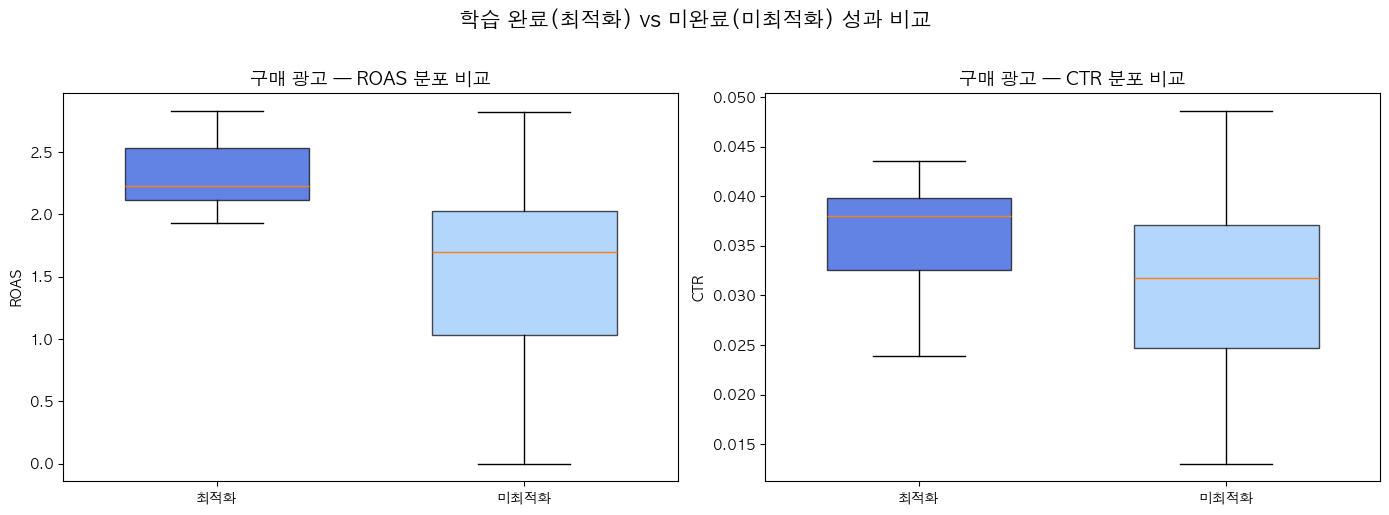

[구매 - 최적화] 광고세트 25개 | 중앙 ROAS: 2.273
[구매 - 미최적화] 광고세트 71개 | 중앙 ROAS: 1.752
[트래픽 - 최적화] 광고세트 21개 | 중앙 CTR: 0.058
[트래픽 - 미최적화] 광고세트 7개 | 중앙 CTR: 0.049


In [4]:
# Box Plot: ROAS 비교 (구매 광고)
color_map = {
    "optimized_conversion": "#1f4ed8",
    "not_optimized_conversion": "#93c5fd",
    "optimized_traffic": "#f97316",
    "not_optimized_traffic": "#fdba74"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 구매 광고 ROAS
conv_ads = ad_summary[ad_summary["ad_goal"] == "conversion"]
for status, color in [("optimized","#1f4ed8"), ("not_optimized","#93c5fd")]:
    data = conv_ads[conv_ads["optimization_status"]==status]["ROAS"].dropna()
    data = data[data < data.quantile(0.95)]  # 극단값 제외
    bp = axes[0].boxplot([data], positions=[0 if status=="optimized" else 1],
                         widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["최적화", "미최적화"])
axes[0].set_title("구매 광고 — ROAS 분포 비교", fontsize=13, fontweight='bold')
axes[0].set_ylabel("ROAS")

# 구매 광고 CTR
for status, color in [("optimized","#1f4ed8"), ("not_optimized","#93c5fd")]:
    data = conv_ads[conv_ads["optimization_status"]==status]["ctr_link_calc"].dropna()
    data = data[data < data.quantile(0.95)]
    bp = axes[1].boxplot([data], positions=[0 if status=="optimized" else 1],
                         widths=0.6, patch_artist=True)
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["최적화", "미최적화"])
axes[1].set_title("구매 광고 — CTR 분포 비교", fontsize=13, fontweight='bold')
axes[1].set_ylabel("CTR")

plt.suptitle("학습 완료(최적화) vs 미완료(미최적화) 성과 비교", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 주요 지표 비교
for goal in ["conversion", "traffic"]:
    goal_kr = "구매" if goal == "conversion" else "트래픽"
    subset = ad_summary[ad_summary["ad_goal"] == goal]
    for status in ["optimized", "not_optimized"]:
        s = subset[subset["optimization_status"]==status]
        status_kr = "최적화" if status == "optimized" else "미최적화"
        metric = "ROAS" if goal == "conversion" else "ctr_link_calc"
        label = "ROAS" if goal == "conversion" else "CTR"
        print(f"[{goal_kr} - {status_kr}] 광고세트 {len(s)}개 | 중앙 {label}: {s[metric].median():.3f}")

### 1-2. 광고비 vs 성과 분포 (4개 그룹)

전체 광고세트를 **최적화 상태 × 광고 목적**으로 4개 그룹으로 나누어,
광고비 대비 성과(ROAS/CTR) 분포를 확인한다.

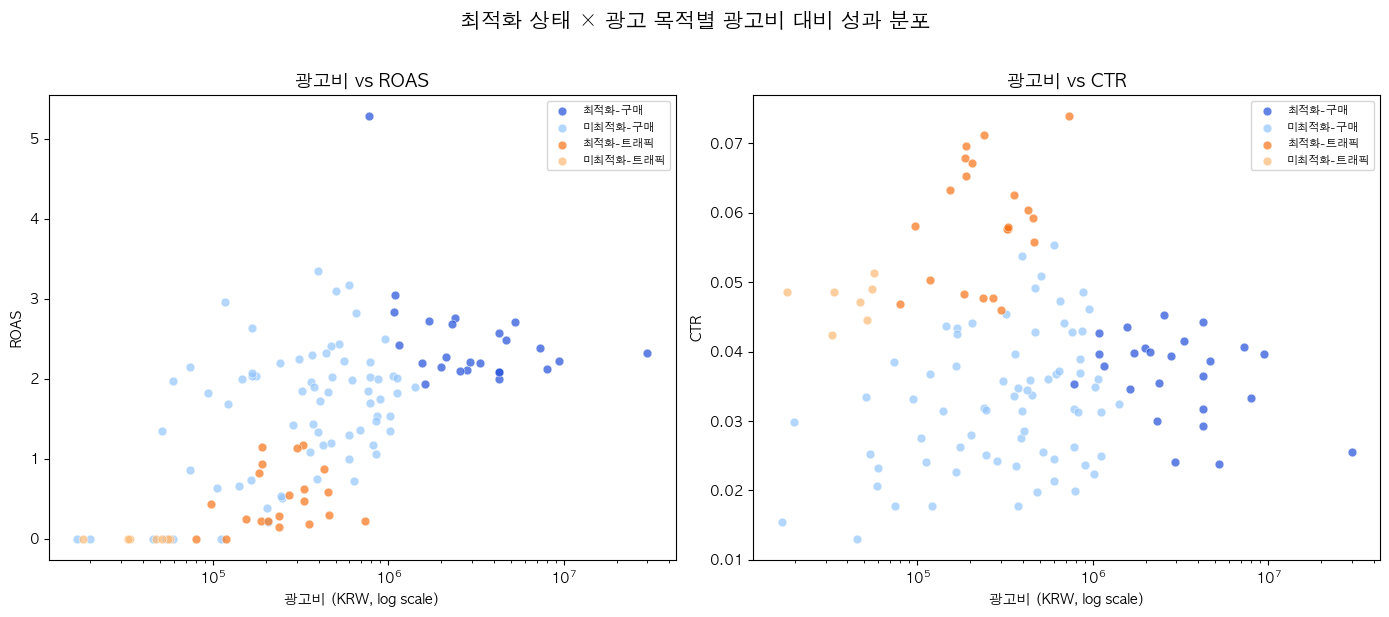

In [5]:
# Scatter: 광고비 vs ROAS / CTR (4개 그룹)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

group_labels = {
    "optimized_conversion": "최적화-구매",
    "not_optimized_conversion": "미최적화-구매",
    "optimized_traffic": "최적화-트래픽",
    "not_optimized_traffic": "미최적화-트래픽"
}

for group, color in color_map.items():
    subset = ad_summary[ad_summary["group"] == group]
    label = group_labels.get(group, group)

    # Spend vs ROAS
    axes[0].scatter(subset["spend"], subset["ROAS"],
                    c=color, label=label, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)
    # Spend vs CTR
    axes[1].scatter(subset["spend"], subset["ctr_link_calc"],
                    c=color, label=label, s=40, alpha=0.7, edgecolors='white', linewidth=0.5)

axes[0].set_xscale('log')
axes[0].set_xlabel('광고비 (KRW, log scale)')
axes[0].set_ylabel('ROAS')
axes[0].set_title('광고비 vs ROAS', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')

axes[1].set_xscale('log')
axes[1].set_xlabel('광고비 (KRW, log scale)')
axes[1].set_ylabel('CTR')
axes[1].set_title('광고비 vs CTR', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('최적화 상태 × 광고 목적별 광고비 대비 성과 분포', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1-3. 미최적화 광고비 비중 분석

미최적화 광고는 개수 기준으로는 높은 비율이지만,
**광고비 기준으로는 약 22%** 수준이다.

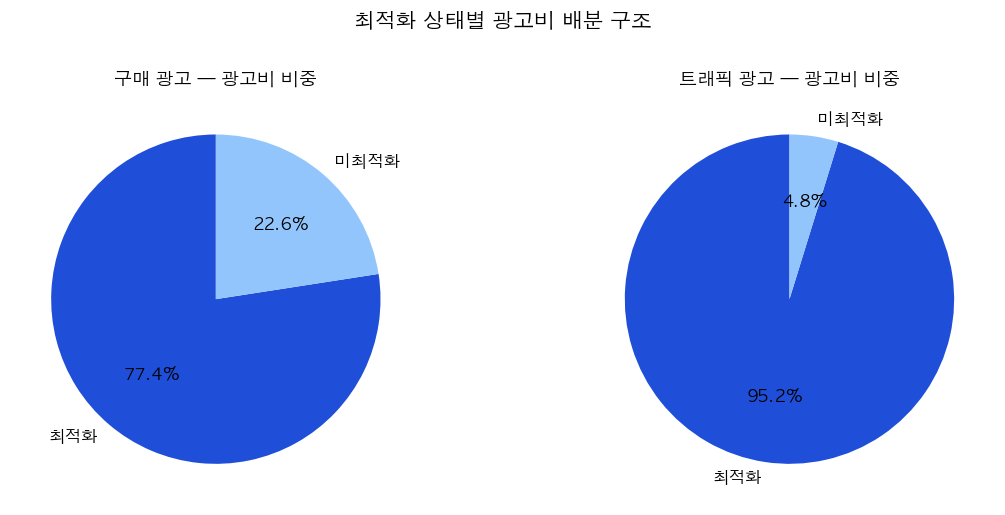

전체 미최적화 광고비 비중: 21.8%


In [6]:
# 광고비 비중 분석
spend_by = ad_summary.groupby(["ad_goal","optimization_status"])["spend"].sum().unstack(fill_value=0)
spend_by["total"] = spend_by.sum(axis=1)
spend_by["미최적화 비중(%)"] = (spend_by["not_optimized"]/spend_by["total"]*100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, goal in enumerate(["conversion","traffic"]):
    goal_kr = "구매" if goal == "conversion" else "트래픽"
    if goal in spend_by.index:
        vals = [spend_by.loc[goal,"optimized"], spend_by.loc[goal,"not_optimized"]]
        axes[i].pie(vals, labels=["최적화","미최적화"], autopct='%1.1f%%',
                    colors=['#1f4ed8','#93c5fd'], startangle=90,
                    textprops={'fontsize':12})
        axes[i].set_title(f'{goal_kr} 광고 — 광고비 비중', fontsize=13, fontweight='bold')

plt.suptitle('최적화 상태별 광고비 배분 구조', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

total_not_opt = spend_by["not_optimized"].sum()
total_all = spend_by["total"].sum()
print(f"전체 미최적화 광고비 비중: {total_not_opt/total_all*100:.1f}%")

### 1-4. 잠재 광고 식별 — 조기 종료 광고 중 살릴 광고가 있는가?

7일 미만 조기 종료된 미최적화 광고를, **최적화 광고의 초기 일별 성과 Q1(하위 25%)**과
비교하여 잠재력이 있는 광고를 식별한다.

**빨간 선(Q1 기준선)** 위에 위치한 광고는 잠재 광고로 판단할 수 있다.

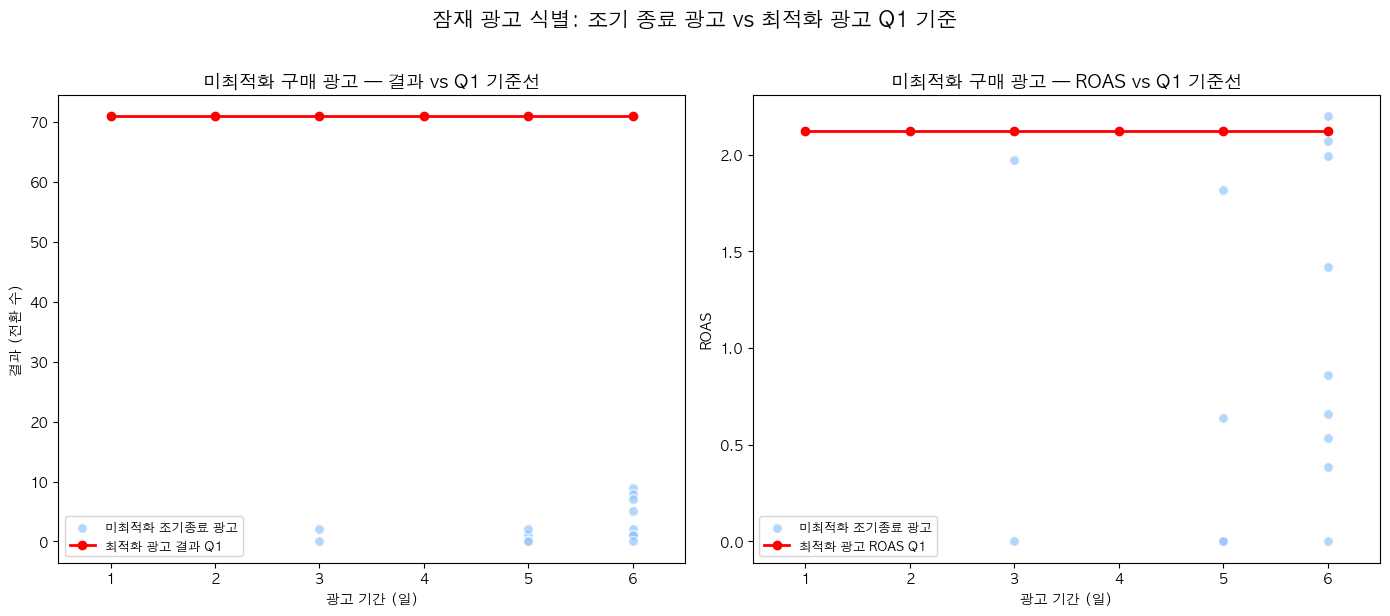

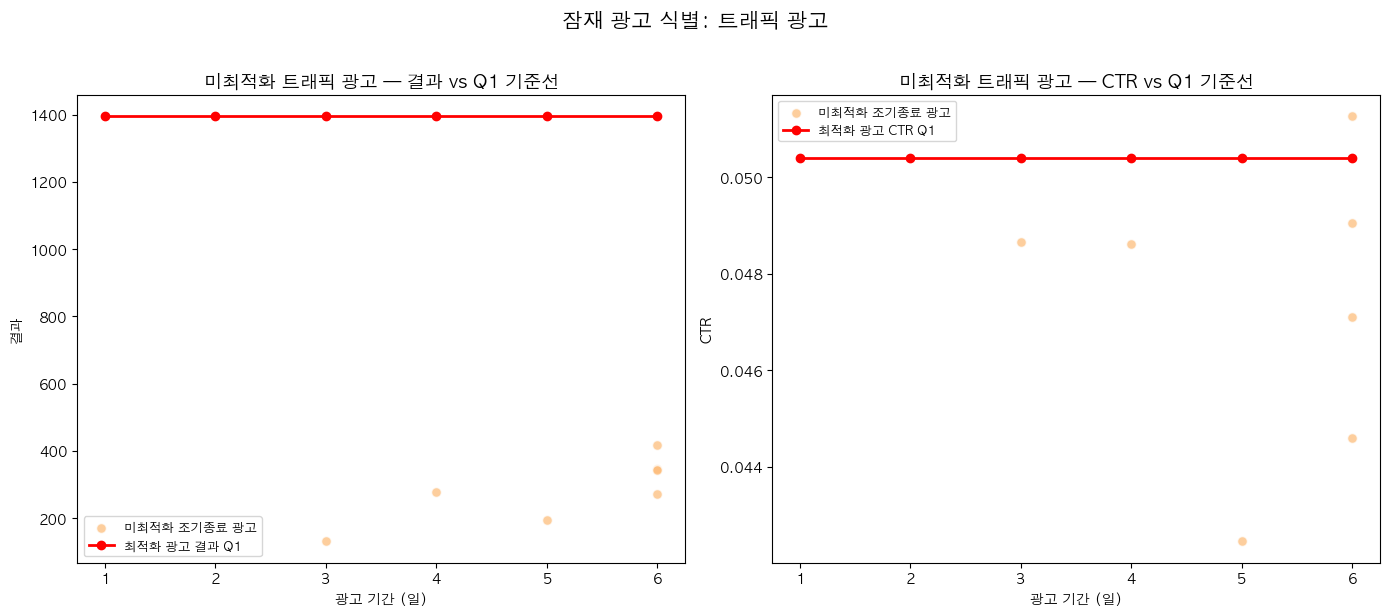

→ 초기 3~6일 구매 5~8건 / ROAS 1.5+ 달성 시 최소 7일 유지 권장


In [7]:
# 잠재 광고 식별: 최적화 광고 초기 일별 Q1 벤치마크 vs 미최적화 조기 종료 광고
# (PPT 슬라이드 9에 해당하는 핵심 차트)

# 최적화 구매 광고의 초기 일별 성과 Q1 계산
opt_conv = ad_summary[(ad_summary["group"]=="optimized_conversion")].copy()
not_opt_conv = ad_summary[
    (ad_summary["group"]=="not_optimized_conversion") &
    (ad_summary["ad_days"] < 7)
].copy()

# 일별 Q1 벤치마크 생성 (최적화 광고 기준)
conv_q1_by_day = []
for d in range(1, 7):
    opt_at_day = opt_conv[opt_conv["ad_days"] >= d]
    if len(opt_at_day) > 0:
        conv_q1_by_day.append({
            "ad_days": d,
            "result_q1": opt_at_day["results"].quantile(0.25),
            "roas_q1": opt_at_day["ROAS"].quantile(0.25)
        })
conv_q1_df = pd.DataFrame(conv_q1_by_day)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 결과 수 비교
axes[0].scatter(not_opt_conv["ad_days"], not_opt_conv["results"],
                c='#93c5fd', s=50, alpha=0.7, edgecolors='white', label='미최적화 조기종료 광고')
axes[0].plot(conv_q1_df["ad_days"], conv_q1_df["result_q1"],
             'r-o', linewidth=2, markersize=6, label='최적화 광고 결과 Q1')
axes[0].set_xlabel('광고 기간 (일)')
axes[0].set_ylabel('결과 (전환 수)')
axes[0].set_title('미최적화 구매 광고 — 결과 vs Q1 기준선', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 7))
axes[0].legend(fontsize=9)
axes[0].set_xlim(0.5, 6.5)

# ROAS 비교
axes[1].scatter(not_opt_conv["ad_days"], not_opt_conv["ROAS"],
                c='#93c5fd', s=50, alpha=0.7, edgecolors='white', label='미최적화 조기종료 광고')
axes[1].plot(conv_q1_df["ad_days"], conv_q1_df["roas_q1"],
             'r-o', linewidth=2, markersize=6, label='최적화 광고 ROAS Q1')
axes[1].set_xlabel('광고 기간 (일)')
axes[1].set_ylabel('ROAS')
axes[1].set_title('미최적화 구매 광고 — ROAS vs Q1 기준선', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 7))
axes[1].legend(fontsize=9)
axes[1].set_xlim(0.5, 6.5)

plt.suptitle('잠재 광고 식별: 조기 종료 광고 vs 최적화 광고 Q1 기준', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 트래픽 광고도 동일하게
opt_trf = ad_summary[(ad_summary["group"]=="optimized_traffic")].copy()
not_opt_trf = ad_summary[
    (ad_summary["group"]=="not_optimized_traffic") &
    (ad_summary["ad_days"] < 7)
].copy()

if len(not_opt_trf) > 0:
    trf_q1_by_day = []
    for d in range(1, 7):
        opt_at_day = opt_trf[opt_trf["ad_days"] >= d]
        if len(opt_at_day) > 0:
            trf_q1_by_day.append({
                "ad_days": d,
                "result_q1": opt_at_day["results"].quantile(0.25),
                "ctr_q1": opt_at_day["ctr_link_calc"].quantile(0.25)
            })
    trf_q1_df = pd.DataFrame(trf_q1_by_day)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].scatter(not_opt_trf["ad_days"], not_opt_trf["results"],
                    c='#fdba74', s=50, alpha=0.7, edgecolors='white', label='미최적화 조기종료 광고')
    axes[0].plot(trf_q1_df["ad_days"], trf_q1_df["result_q1"],
                 'r-o', linewidth=2, markersize=6, label='최적화 광고 결과 Q1')
    axes[0].set_xlabel('광고 기간 (일)')
    axes[0].set_ylabel('결과')
    axes[0].set_title('미최적화 트래픽 광고 — 결과 vs Q1 기준선', fontsize=13, fontweight='bold')
    axes[0].set_xticks(range(1, 7))
    axes[0].legend(fontsize=9)

    axes[1].scatter(not_opt_trf["ad_days"], not_opt_trf["ctr_link_calc"],
                    c='#fdba74', s=50, alpha=0.7, edgecolors='white', label='미최적화 조기종료 광고')
    axes[1].plot(trf_q1_df["ad_days"], trf_q1_df["ctr_q1"],
                 'r-o', linewidth=2, markersize=6, label='최적화 광고 CTR Q1')
    axes[1].set_xlabel('광고 기간 (일)')
    axes[1].set_ylabel('CTR')
    axes[1].set_title('미최적화 트래픽 광고 — CTR vs Q1 기준선', fontsize=13, fontweight='bold')
    axes[1].set_xticks(range(1, 7))
    axes[1].legend(fontsize=9)

    plt.suptitle('잠재 광고 식별: 트래픽 광고', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print("→ 초기 3~6일 구매 5~8건 / ROAS 1.5+ 달성 시 최소 7일 유지 권장")

### 1-5. 비효율 광고 식별 — 최적화된 광고 중에서도 낭비되는 광고가 있는가?

학습 완료(최적화) 광고를 대상으로 **광고비 × 성과 지표의 중앙값**을 기준으로
사분면을 나누어 비효율 광고를 식별한다.

- **2사분면** (광고비↓ 성과↑): 효율 광고 구간
- **4사분면** (광고비↑ 성과↓): 비효율 광고 구간 → 소재 교체 또는 예산 축소

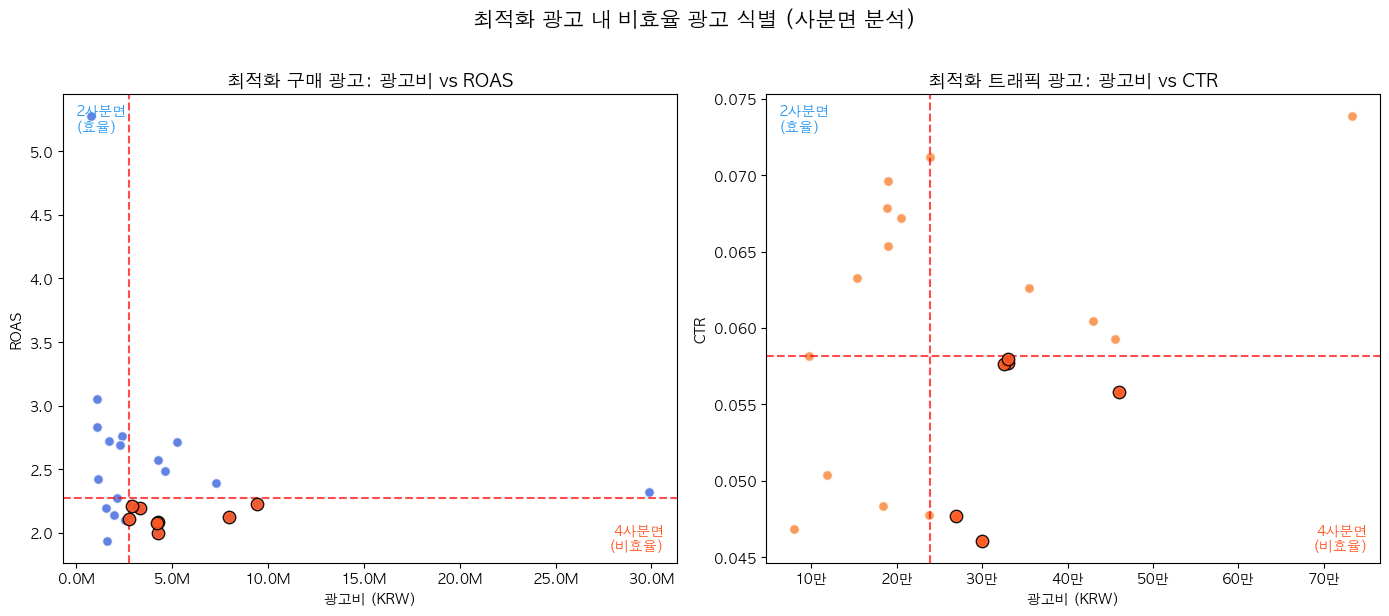

[구매] 4사분면 비효율 광고: 8개 / 전체 최적화: 25개
[트래픽] 4사분면 비효율 광고: 6개 / 전체 최적화: 21개

→ 4사분면 광고는 소재 교체 또는 예산 축소 → 2사분면(효율) 광고로 예산 재배분


In [8]:
# 사분면 분석: 최적화 광고 내 비효율 식별 (PPT 슬라이드 10 핵심 차트)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1) 최적화 구매 광고: 광고비 vs ROAS
opt_conv = ad_summary[ad_summary["group"]=="optimized_conversion"].copy()
conv_spend_med = opt_conv["spend"].median()
conv_roas_med = opt_conv["ROAS"].median()

axes[0].scatter(opt_conv["spend"], opt_conv["ROAS"],
                c='#1f4ed8', s=50, alpha=0.7, edgecolors='white')
axes[0].axvline(conv_spend_med, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].axhline(conv_roas_med, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].set_xlabel('광고비 (KRW)')
axes[0].set_ylabel('ROAS')
axes[0].set_title('최적화 구매 광고: 광고비 vs ROAS', fontsize=13, fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# 사분면 라벨
axes[0].text(0.02, 0.98, '2사분면\n(효율)', transform=axes[0].transAxes,
             fontsize=10, va='top', ha='left', color='#2196F3', fontweight='bold')
axes[0].text(0.98, 0.02, '4사분면\n(비효율)', transform=axes[0].transAxes,
             fontsize=10, va='bottom', ha='right', color='#FF5722', fontweight='bold')

# 비효율 광고 하이라이트
ineff_conv = opt_conv[(opt_conv["spend"]>=conv_spend_med) & (opt_conv["ROAS"]<conv_roas_med)]
axes[0].scatter(ineff_conv["spend"], ineff_conv["ROAS"],
                c='#FF5722', s=80, alpha=0.9, edgecolors='black', linewidth=1, zorder=5)

# 2) 최적화 트래픽 광고: 광고비 vs CTR
opt_trf = ad_summary[ad_summary["group"]=="optimized_traffic"].copy()
trf_spend_med = opt_trf["spend"].median()
trf_ctr_med = opt_trf["ctr_link_calc"].median()

axes[1].scatter(opt_trf["spend"], opt_trf["ctr_link_calc"],
                c='#f97316', s=50, alpha=0.7, edgecolors='white')
axes[1].axvline(trf_spend_med, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].axhline(trf_ctr_med, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[1].set_xlabel('광고비 (KRW)')
axes[1].set_ylabel('CTR')
axes[1].set_title('최적화 트래픽 광고: 광고비 vs CTR', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1e4:.0f}만'))

axes[1].text(0.02, 0.98, '2사분면\n(효율)', transform=axes[1].transAxes,
             fontsize=10, va='top', ha='left', color='#2196F3', fontweight='bold')
axes[1].text(0.98, 0.02, '4사분면\n(비효율)', transform=axes[1].transAxes,
             fontsize=10, va='bottom', ha='right', color='#FF5722', fontweight='bold')

ineff_trf = opt_trf[(opt_trf["spend"]>=trf_spend_med) & (opt_trf["ctr_link_calc"]<trf_ctr_med)]
axes[1].scatter(ineff_trf["spend"], ineff_trf["ctr_link_calc"],
                c='#FF5722', s=80, alpha=0.9, edgecolors='black', linewidth=1, zorder=5)

plt.suptitle('최적화 광고 내 비효율 광고 식별 (사분면 분석)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"[구매] 4사분면 비효율 광고: {len(ineff_conv)}개 / 전체 최적화: {len(opt_conv)}개")
print(f"[트래픽] 4사분면 비효율 광고: {len(ineff_trf)}개 / 전체 최적화: {len(opt_trf)}개")
print("\n→ 4사분면 광고는 소재 교체 또는 예산 축소 → 2사분면(효율) 광고로 예산 재배분")

### 1-6. 전체 광고 CTR × ROAS 성과 유형 분포

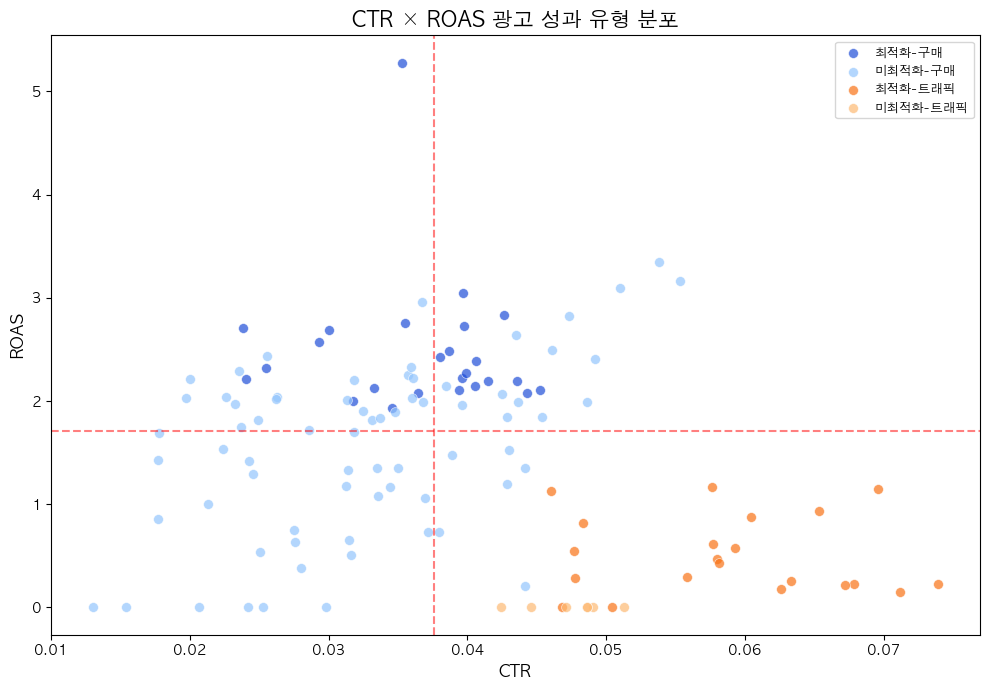

In [9]:
# CTR × ROAS 사분면 분포 (전체 광고)
fig, ax = plt.subplots(figsize=(10, 7))

ctr_med = ad_summary["ctr_link_calc"].median()
roas_med = ad_summary["ROAS"].median()

for group, color in color_map.items():
    subset = ad_summary[ad_summary["group"]==group]
    label = group_labels.get(group, group)
    ax.scatter(subset["ctr_link_calc"], subset["ROAS"],
               c=color, label=label, s=50, alpha=0.7, edgecolors='white', linewidth=0.5)

ax.axvline(ctr_med, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axhline(roas_med, color='red', linestyle='--', alpha=0.5, linewidth=1.5)

ax.set_xlabel('CTR', fontsize=12)
ax.set_ylabel('ROAS', fontsize=12)
ax.set_title('CTR × ROAS 광고 성과 유형 분포', fontsize=15, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

---
## PART 2 — 광고 콘텐츠 분석 (Content)

> "무엇이 성과를 만드는가?"

광고 본문 텍스트를 키워드 기반으로 태깅하고, 메시지 유형별 성과를 비교한다.

In [10]:
# 광고 단위 집계 (메시지 분석용)
import re

ad_level = df.groupby("광고 ID", as_index=False).agg({
    "광고 이름":"first", "캠페인 이름":"first", "광고 세트 이름":"first",
    "성과 목표":"first", "headline":"first", "설명":"first",
    "본문(광고 설정)":"first", "product_name":"first",
    "노출":"sum", "링크 클릭":"sum", "구매":"sum",
    "구매 전환값":"sum", "지출 금액 (KRW)":"sum", "랜딩 페이지 조회":"sum"
})

ad_level["CTR"] = ad_level["링크 클릭"] / ad_level["노출"]
ad_level["CVR"] = np.where(ad_level["링크 클릭"]>0, ad_level["구매"]/ad_level["링크 클릭"], 0)
ad_level["ROAS"] = np.where(ad_level["지출 금액 (KRW)"]>0,
    ad_level["구매 전환값"]/ad_level["지출 금액 (KRW)"], 0)

purchase_ads = ad_level[ad_level["구매"] > 0].copy()

for col in ["headline","설명","본문(광고 설정)"]:
    purchase_ads[col] = purchase_ads[col].fillna("").astype(str)

purchase_ads["message_text"] = (
    purchase_ads["headline"].str.strip() + " " +
    purchase_ads["설명"].str.strip() + " " +
    purchase_ads["본문(광고 설정)"].str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()

purchase_ads = purchase_ads[~purchase_ads["message_text"].str.contains("{{", na=False)].copy()
print(f"구매 발생 광고 (DPA 제외): {len(purchase_ads)}개")

구매 발생 광고 (DPA 제외): 298개


### 2-1. 메시지 유형 분류 및 성과 비교

- **의미형**: 선물, 의미, 행운, 관계 등 구매 동기 유도
- **제품 강조형**: 디자인, 소재, 착용 스타일 등 제품 정보
- **이벤트형**: 할인, 증정, 시즌 이벤트 등 혜택 강조

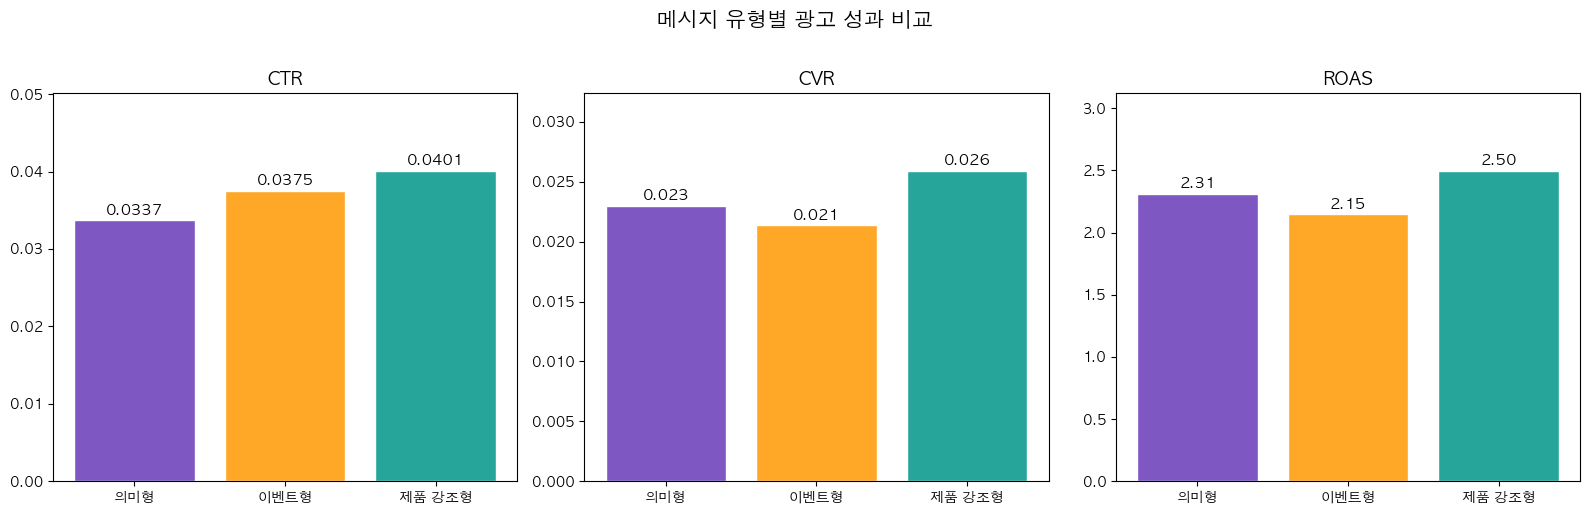

  의미형: 212개 (85.0%) | ROAS 2.31
  이벤트형: 42개 (4.9%) | ROAS 2.15
  제품 강조형: 44개 (10.1%) | ROAS 2.50


In [11]:
# 키워드 기반 메시지 유형 자동 태깅
event_kw = ["할인","세일","특가","혜택","쿠폰","증정","이벤트","프로모션",
            "1+1","무료","한정","단독","사은품","특별가"]
product_kw = ["디자인","소재","원석","실버","골드","14k","18k","도금",
              "퀄리티","디테일","사이즈","착용","아이템","컬러",
              "고급스러운","스타일","룩"]
meaning_kw = ["선물","마음","의미","행운","소원","응원","위로","사랑","인연","행복",
              "성공","보호","부모","가족","추억","소중한","특별한","함께","전하세요",
              "당신에게","나를 위한","진심","감성","기념"]
strong_pairs = [["선물","행운"],["선물","마음"],["행운","가족"],
                ["응원","마음"],["사랑","선물"],["인연","행운"]]

def auto_tag(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    e_cnt = sum(kw.lower() in text for kw in event_kw)
    p_cnt = sum(kw.lower() in text for kw in product_kw)
    m_cnt = sum(kw.lower() in text for kw in meaning_kw)
    for pair in strong_pairs:
        if all(p.lower() in text for p in pair): return "의미형"
    if m_cnt >= 2: return "의미형"
    if e_cnt >= 1: return "이벤트형"
    if p_cnt >= 1: return "제품 강조형"
    if m_cnt >= 1: return "의미형"
    return "미분류"

purchase_ads["message_type"] = purchase_ads["message_text"].apply(auto_tag)

# 유형별 성과 집계
msg_perf = purchase_ads.groupby("message_type").agg(
    광고수=("광고 ID","nunique"), 노출합=("노출","sum"),
    클릭합=("링크 클릭","sum"), 구매합=("구매","sum"),
    매출합=("구매 전환값","sum"), 광고비합=("지출 금액 (KRW)","sum")
).reset_index()
msg_perf["CTR"] = msg_perf["클릭합"]/msg_perf["노출합"]
msg_perf["CVR"] = msg_perf["구매합"]/msg_perf["클릭합"]
msg_perf["ROAS"] = msg_perf["매출합"]/msg_perf["광고비합"]
msg_perf["광고비 비중(%)"] = (msg_perf["광고비합"]/msg_perf["광고비합"].sum()*100).round(1)

msg_disp = msg_perf[msg_perf["message_type"]!="미분류"].copy()

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors = {"의미형":"#7E57C2","제품 강조형":"#26A69A","이벤트형":"#FFA726"}
types = msg_disp["message_type"].tolist()
colors = [bar_colors.get(t,"#999") for t in types]

for i, (metric, title) in enumerate([("CTR","CTR"),("CVR","CVR"),("ROAS","ROAS")]):
    bars = axes[i].bar(types, msg_disp[metric], color=colors, edgecolor='white')
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, msg_disp[metric]):
        fmt = f'{val:.4f}' if metric=="CTR" else f'{val:.3f}' if metric=="CVR" else f'{val:.2f}'
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                     fmt, ha='center', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, msg_disp[metric].max()*1.25)

plt.suptitle('메시지 유형별 광고 성과 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for _, r in msg_disp.iterrows():
    print(f"  {r['message_type']}: {int(r['광고수'])}개 ({r['광고비 비중(%)']:.1f}%) | ROAS {r['ROAS']:.2f}")

### 2-2. 의미형 메시지 심층 분석 (관계 vs 감정)

- 나(SELF)보다 **타인(관계) 지향** 메시지가 성과 우수
- **행복(HAPPINESS)** 메시지가 ROAS 최고, 행운(LUCK)은 상대적 저효율

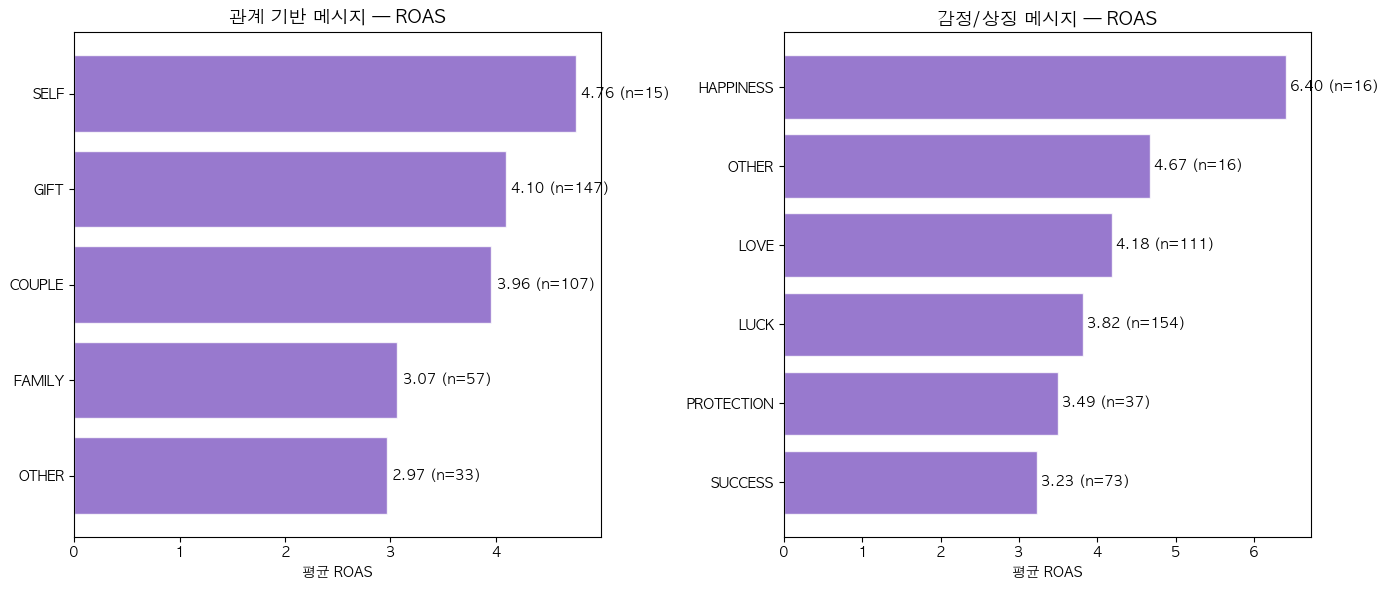

In [12]:
# 의미형 세분류
meaning_ads = purchase_ads[purchase_ads["message_type"]=="의미형"].copy()

relation_kw = {
    "COUPLE":["커플","연인","우리"], "GIFT":["선물","전하세요","드리세요"],
    "FAMILY":["부모","가족","엄마","아빠","자식"], "SELF":["나를 위한","나다운","나만의"]
}
emotion_kw = {
    "HAPPINESS":["행복","기쁨","미소"], "LUCK":["행운","소원","운","부적"],
    "LOVE":["사랑","인연","마음"], "PROTECTION":["보호","지킴","수호"],
    "SUCCESS":["성공","합격","응원"]
}

def tag_sub(text, kw_dict):
    text = str(text).lower()
    return [label for label, kws in kw_dict.items() if any(kw in text for kw in kws)] or ["OTHER"]

meaning_ads["relation_tags"] = meaning_ads["message_text"].apply(lambda x: tag_sub(x, relation_kw))
meaning_ads["emotion_tags"] = meaning_ads["message_text"].apply(lambda x: tag_sub(x, emotion_kw))

# 태그별 성과 집계
def explode_tags(df, tag_col):
    rows = []
    for _, row in df.iterrows():
        for tag in row[tag_col]:
            rows.append({"tag":tag, "ROAS":row["ROAS"], "CTR":row["CTR"]})
    return pd.DataFrame(rows)

rel_df = explode_tags(meaning_ads, "relation_tags")
emo_df = explode_tags(meaning_ads, "emotion_tags")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (data, title) in enumerate([
    (rel_df, "관계 기반 메시지 — ROAS"),
    (emo_df, "감정/상징 메시지 — ROAS")
]):
    grouped = data.groupby("tag").agg(mean_roas=("ROAS","mean"), count=("ROAS","count"))
    grouped = grouped[grouped["count"]>=3].sort_values("mean_roas", ascending=True)

    bars = axes[i].barh(grouped.index, grouped["mean_roas"], color='#7E57C2', alpha=0.8, edgecolor='white')
    for bar, (idx, row) in zip(bars, grouped.iterrows()):
        axes[i].text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
                     f'{row["mean_roas"]:.2f} (n={int(row["count"])})', va='center', fontsize=10)
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('평균 ROAS')

plt.tight_layout()
plt.show()

### 2-3. ROAS 시뮬레이션 (LUCK → HAPPINESS 전환)

행운(LUCK) 메시지 일부를 행복(HAPPINESS) 메시지로 전환 시 ROAS 변화를 가중평균으로 시뮬레이션.

LUCK: 154개 (ROAS 3.82) | HAPPINESS: 16개 (ROAS 6.40)

시나리오               예상 ROAS        개선율
----------------------------------------
AS-IS                4.06      0.0%
10% 전환               4.29 +     5.6%
30% 전환               4.76 +    17.2%
50% 전환               5.23 +    28.8%


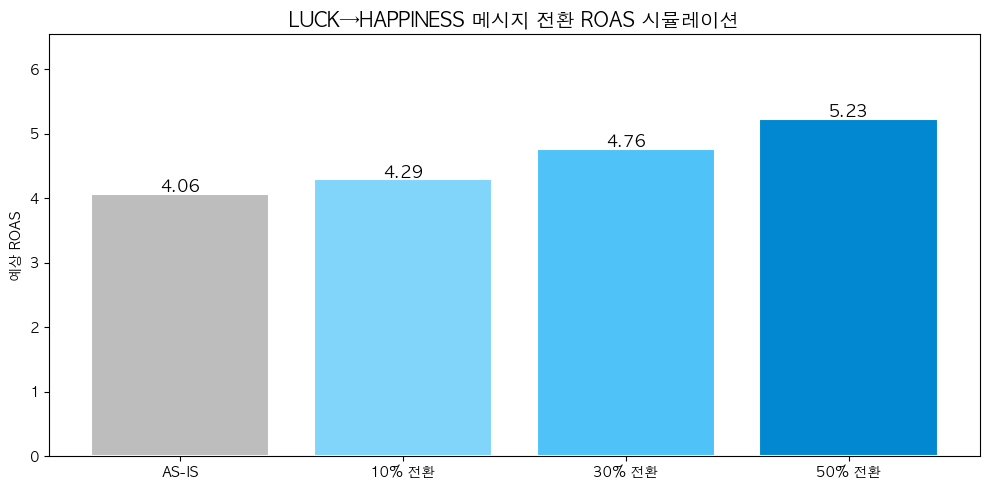

In [13]:
luck_ads = meaning_ads[meaning_ads["emotion_tags"].apply(lambda x: "LUCK" in x)]
happy_ads = meaning_ads[meaning_ads["emotion_tags"].apply(lambda x: "HAPPINESS" in x)]

luck_roas = luck_ads["ROAS"].mean() if len(luck_ads)>0 else 0
happy_roas = happy_ads["ROAS"].mean() if len(happy_ads)>0 else 0
n_luck, n_happy = len(luck_ads), len(happy_ads)
n_total = n_luck + n_happy

if n_total > 0:
    scenarios = [("AS-IS",0), ("10% 전환",0.10), ("30% 전환",0.30), ("50% 전환",0.50)]
    sim_results = []
    for name, shift in scenarios:
        shifted = int(n_luck * shift)
        sim_roas = (luck_roas*(n_luck-shifted) + happy_roas*(n_happy+shifted)) / n_total
        sim_results.append((name, sim_roas))

    baseline = sim_results[0][1]
    print(f"LUCK: {n_luck}개 (ROAS {luck_roas:.2f}) | HAPPINESS: {n_happy}개 (ROAS {happy_roas:.2f})")
    print(f"\n{'시나리오':<15} {'예상 ROAS':>10} {'개선율':>10}")
    print("-"*40)
    for name, roas in sim_results:
        imp = (roas/baseline-1)*100
        print(f"{name:<15} {roas:>9.2f} {'+' if imp>0 else ''}{imp:>8.1f}%")

    fig, ax = plt.subplots(figsize=(10, 5))
    labels = [s[0] for s in sim_results]
    vals = [s[1] for s in sim_results]
    colors_sim = ['#BDBDBD','#81D4FA','#4FC3F7','#0288D1']
    bars = ax.bar(labels, vals, color=colors_sim, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')
    ax.set_title('LUCK→HAPPINESS 메시지 전환 ROAS 시뮬레이션', fontsize=14, fontweight='bold')
    ax.set_ylabel('예상 ROAS')
    ax.set_ylim(0, max(vals)*1.25)
    plt.tight_layout()
    plt.show()

### 2-4. 소재 유형별 ROAS 분포 분석

광고 소재를 4가지 유형으로 태깅하여 ROAS 분포를 비교한다.

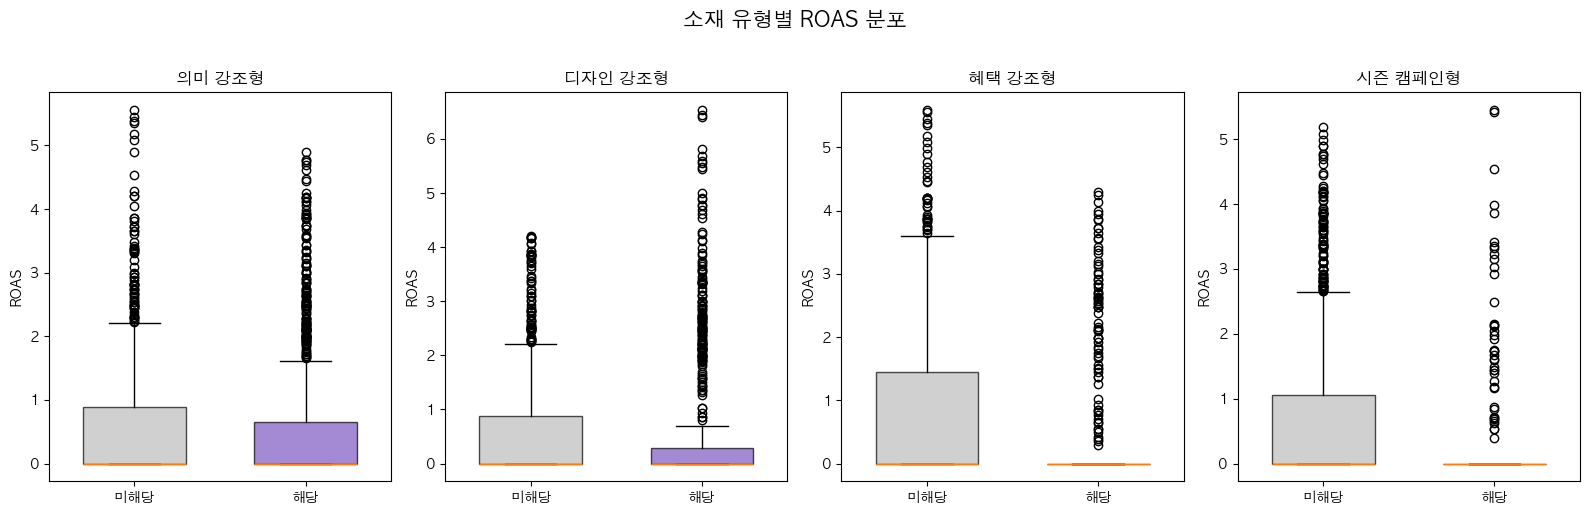

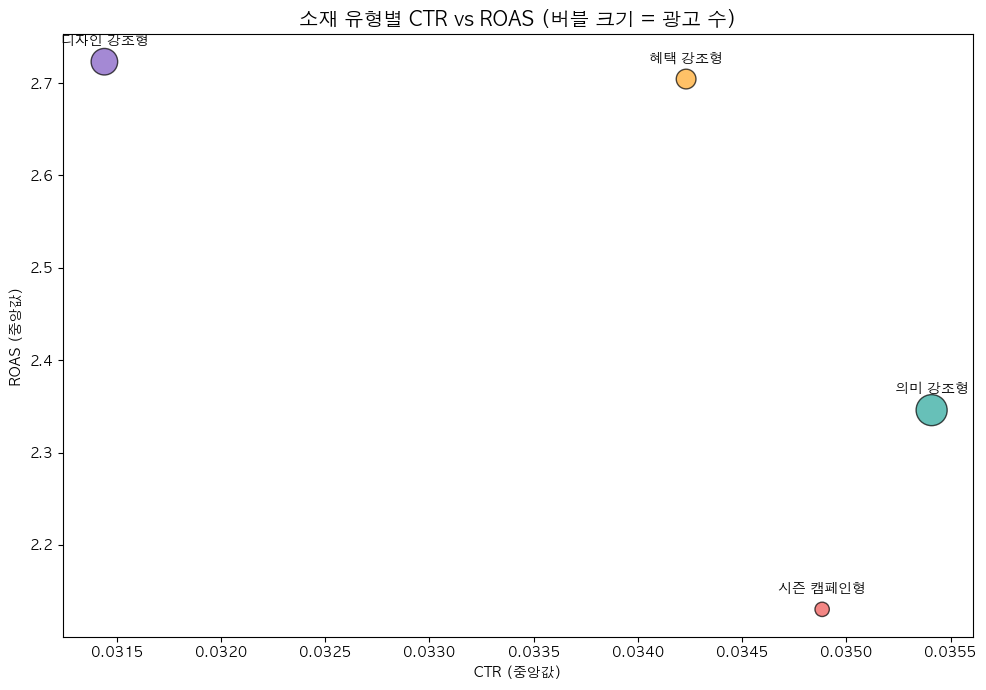

In [14]:
# ads_tagged.csv 기반 소재 유형별 분석
try:
    tag = pd.read_csv('ads_tagged.csv', encoding='utf-8-sig')

    tag_cols = ["tag_의미 강조형","tag_디자인 강조형","tag_혜택 강조형","tag_시즌 캠페인형"]
    available_tags = [c for c in tag_cols if c in tag.columns]

    fig, axes = plt.subplots(1, len(available_tags), figsize=(4*len(available_tags), 5))
    if len(available_tags) == 1:
        axes = [axes]

    for i, col in enumerate(available_tags):
        tag_name = col.replace("tag_","")
        data_0 = tag[tag[col]==0]["roas_calc"].dropna()
        data_1 = tag[tag[col]==1]["roas_calc"].dropna()
        # 극단값 제외
        data_0 = data_0[data_0 < data_0.quantile(0.95)]
        data_1 = data_1[data_1 < data_1.quantile(0.95)]

        bp = axes[i].boxplot([data_0, data_1], labels=["미해당","해당"],
                             patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor('#BDBDBD')
        bp['boxes'][1].set_facecolor('#7E57C2')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_alpha(0.7)
        axes[i].set_title(tag_name, fontsize=12, fontweight='bold')
        axes[i].set_ylabel('ROAS')

    plt.suptitle('소재 유형별 ROAS 분포', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # 태그별 CTR vs ROAS 버블 차트
    tag_unique = tag.groupby("광고 ID", as_index=False).agg({
        "ctr_link_calc":"median", "roas_calc":"median", "purchase_value":"sum",
        **{col:"max" for col in available_tags}
    })

    rows = []
    for col in available_tags:
        d = tag_unique[(tag_unique[col]==1) & (tag_unique["roas_calc"]>0)]
        if len(d) > 0:
            rows.append({
                "tag": col.replace("tag_",""),
                "CTR_median": d["ctr_link_calc"].median(),
                "ROAS_median": d["roas_calc"].median(),
                "매출합": d["purchase_value"].sum(),
                "광고수": len(d)
            })

    bubble_df = pd.DataFrame(rows)
    if len(bubble_df) > 0:
        fig, ax = plt.subplots(figsize=(10, 7))
        sizes = bubble_df["광고수"] / bubble_df["광고수"].max() * 500
        scatter = ax.scatter(bubble_df["CTR_median"], bubble_df["ROAS_median"],
                            s=sizes, c=['#26A69A','#7E57C2','#FFA726','#EF5350'][:len(bubble_df)],
                            alpha=0.7, edgecolors='black', linewidth=1)
        for _, row in bubble_df.iterrows():
            ax.annotate(row["tag"], (row["CTR_median"], row["ROAS_median"]),
                       textcoords="offset points", xytext=(0,12),
                       ha='center', fontsize=10, fontweight='bold')
        ax.set_xlabel('CTR (중앙값)')
        ax.set_ylabel('ROAS (중앙값)')
        ax.set_title('소재 유형별 CTR vs ROAS (버블 크기 = 광고 수)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print("ads_tagged.csv 파일을 찾을 수 없습니다.")

### 2-5. 제품별 최적 소재 차이

- **원석팔찌**: 제품 가치·효익 중심 소재 → 전환 우수
- **커플세트**: 감성 스토리·관계 중심 소재 → ROAS 압도적

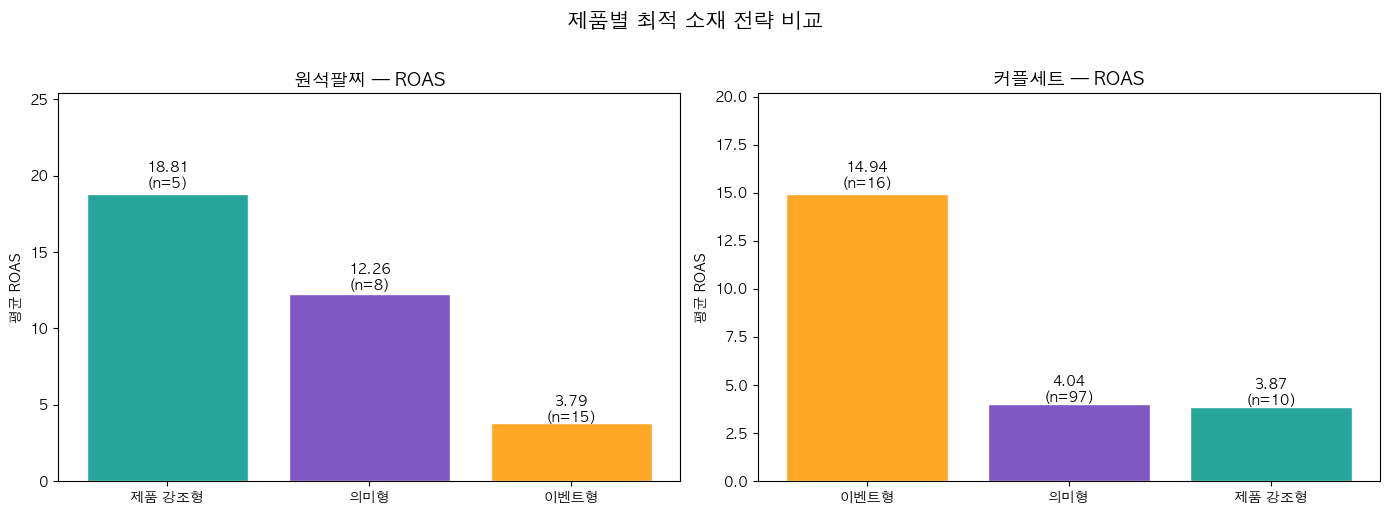

In [15]:
# 제품별 메시지 유형 성과
def categorize_product(name):
    if pd.isna(name): return "기타"
    name = str(name).lower()
    if any(kw in name for kw in ["팔찌","bracelet","원석"]): return "원석팔찌"
    elif any(kw in name for kw in ["커플","couple","세트"]): return "커플세트"
    return "기타"

purchase_ads["product_cat"] = purchase_ads["product_name"].apply(categorize_product)
main_prods = purchase_ads[purchase_ads["product_cat"].isin(["원석팔찌","커플세트"])]

prod_msg = main_prods.groupby(["product_cat","message_type"]).agg(
    count=("광고 ID","nunique"), mean_roas=("ROAS","mean")
).reset_index()
prod_msg = prod_msg[(prod_msg["message_type"]!="미분류") & (prod_msg["count"]>=3)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors_msg = {"의미형":"#7E57C2","제품 강조형":"#26A69A","이벤트형":"#FFA726"}

for i, product in enumerate(["원석팔찌","커플세트"]):
    subset = prod_msg[prod_msg["product_cat"]==product].sort_values("mean_roas", ascending=False)
    colors_p = [bar_colors_msg.get(t,"#999") for t in subset["message_type"]]
    bars = axes[i].bar(subset["message_type"], subset["mean_roas"], color=colors_p, edgecolor='white')
    for bar, (_, row) in zip(bars, subset.iterrows()):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                     f'{row["mean_roas"]:.2f}\n(n={int(row["count"])})',
                     ha='center', fontsize=10, fontweight='bold')
    axes[i].set_title(f'{product} — ROAS', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('평균 ROAS')
    axes[i].set_ylim(0, subset["mean_roas"].max()*1.35 if len(subset)>0 else 1)

plt.suptitle('제품별 최적 소재 전략 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## PART 3 — 결론 및 실행 로드맵

> "어떻게 실행할 것인가?"

### 광고 성과를 결정하는 3가지 요소

| 요소 | 핵심 발견 | 실행 방향 |
|------|----------|----------|
| **운영 구조** | 구매 광고 예산의 일부가 미최적화 상태에서 소진 | 최적화 전/후 운영 기준 적용 |
| **콘텐츠 메시지** | 행복+관계 조합이 ROAS 최고 효율 | 성과 중심 메시지 비중 확대 |
| **타겟·맥락** | 핵심 타겟 여성, 제품별 최적 소재 상이 | 맥락에 따른 소재 역할 분리 |

### 3단계 실행 로드맵

| 단계 | 시기 | 실행 항목 |
|------|------|----------|
| **1단계** | 즉시 | 조기 종료 방지 기준 + 비효율 광고 관리 기준 적용 |
| **2단계** | 1개월 내 | 비효율 예산 재배분 + HAPPINESS A/B 테스트 + 제품 강조형 확대 |
| **3단계** | 3개월 내 | 성과 광고 스케일업 + 운영 기준 재설정 + 주간 점검 프로세스 |

> **"조기 종료 방지 → 비효율 관리 → 성과 메시지 확대"의 선순환 구조를 만든다**